In [ ]:
import numpy as np
from scipy import stats
from sys import getsizeof
import matplotlib.pyplot as plt
from model_utils import *

Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9372549].


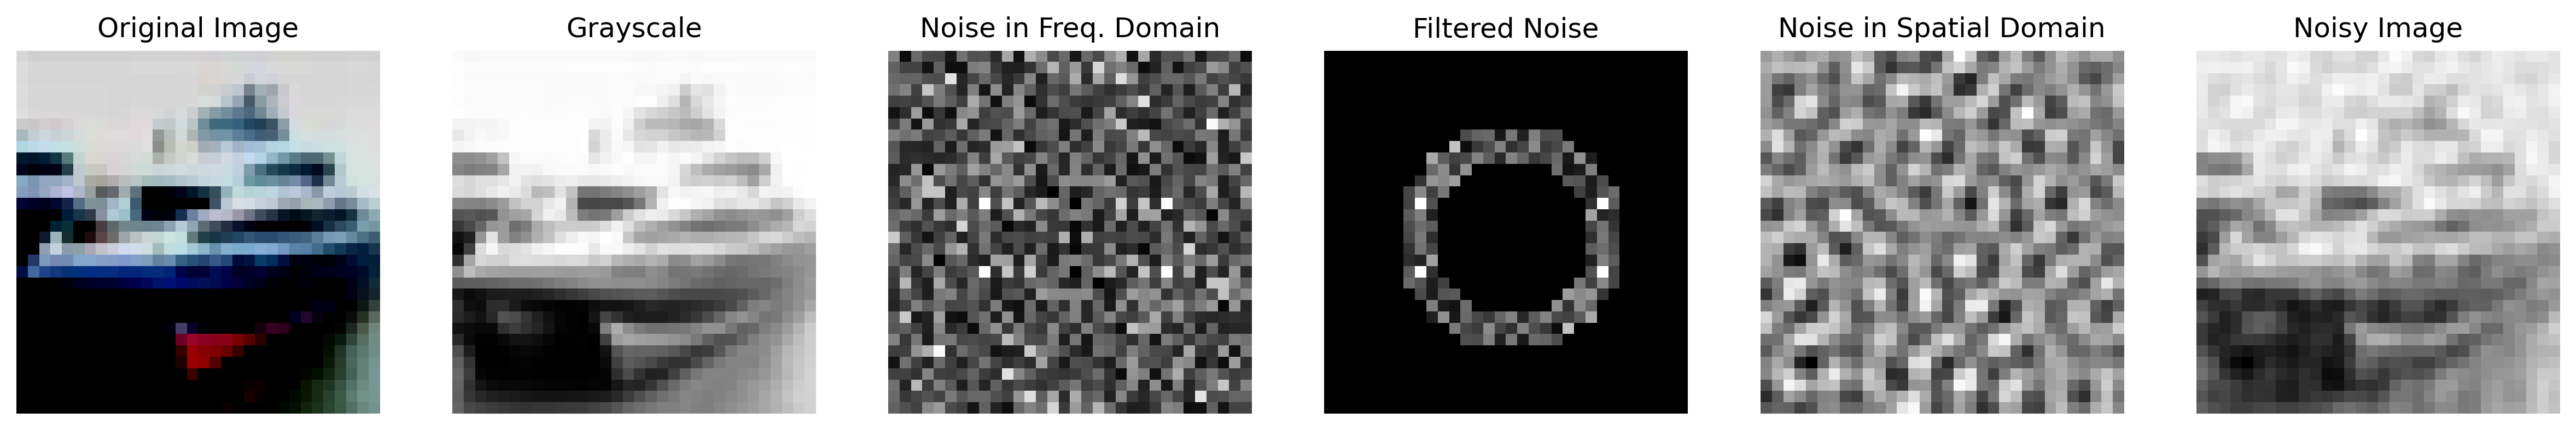

In [25]:
test_images, _ = load_cifar_list()
img = test_images[1]
img = np.transpose(img, (1, 2, 0))
img_gray = 0.2989 * img[:,:,0] + 0.5870 * img[:,:,1] + 0.1140 * img[:,:,2]

sample_image = img_gray
noise_level = 0.25
circle_mask = draw_circle(shape=sample_image.shape,diameter=7)
outer_circle_mask = draw_circle(shape=sample_image.shape, diameter=10)
ring_mask = outer_circle_mask & ~circle_mask

noise = np.random.randn(*sample_image.shape)
noise_fft = np.fft.fftshift(np.fft.fft2(noise))
noise_fft_ring = noise_fft * ring_mask * noise_level
frequency_noise = np.fft.ifft2(np.fft.ifftshift(noise_fft_ring))

noisy_img = sample_image + np.real(frequency_noise)

fig, axes = plt.subplots(1, 6, figsize=(20, 5), dpi=300)

axes[0].imshow(img)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')

axes[2].imshow(np.abs(noise_fft), cmap='gray')
axes[2].set_title('Noise in Freq. Domain')
axes[2].axis('off')

axes[3].imshow(np.abs(noise_fft_ring), cmap='gray')
axes[3].set_title('Filtered Noise')
axes[3].axis('off')

axes[4].imshow(np.real(frequency_noise), cmap='gray')
axes[4].set_title('Noise in Spatial Domain')
axes[4].axis('off')

axes[5].imshow((noisy_img), cmap='gray')
axes[5].set_title('Noisy Image')
axes[5].axis('off')

plt.show()

In [12]:
accuracyarray = np.load('Results/cifar_avg_frequency_classification.npy', allow_pickle=True)
stdarray = np.load('Results/cifar_std_frequency_classification.npy', allow_pickle=True)

In [17]:
accuracyarray.item()

{'sae_clean_acc': 0.39776666666666666,
 'dae_clean_acc': 0.40526666666666666,
 'sae_low_freq_acc': 0.1523,
 'dae_low_freq_acc': 0.1457,
 'sae_mid_freq_acc': 0.16893333333333335,
 'dae_mid_freq_acc': 0.14196666666666669,
 'sae_high_freq_acc': 0.251,
 'dae_high_freq_acc': 0.22456666666666666}

In [15]:
cifar_size_ls = [6,   6,   6,   6,   6,   6,    # 6
                10,  10,  10,  10,  10,  10,    # 6
                16,  16,  16,  16,  16,  16,    # 6
                28,  28,  28,  28,  28,  28,    # 6
                48,  48,  48,  48,  48,  48,  48,  48, 48, # 9
                90,  90,  90,  90,  90,  90,  90,  90,  90,  90, #10
                128, 128, 128, 128, 128, 128, 128, 128, 128, 128,
                128, 128, 128, 128, 128, 128, 128 # 17
                ]

print(cifar_size_ls[42])

90


In [17]:
import numpy as np
a = np.load('Results/cifar_sae_rfs.npy')
a.shape

(2, 60, 128, 3, 32, 32)

In [ ]:
def load_and_print_pvalues(dataset="mnist"):
    """
    Load results and print p-values for each noise type.
    
    Args:
        dataset: Dataset name ('mnist' or 'cifar')
    """
    # Load all individual results (not just averages)
    all_results_file = f"Results/{dataset}_all_frequency_classification.npy"
    try:
        all_results = np.load(all_results_file, allow_pickle=True).item()
    except FileNotFoundError:
        print(f"Error: Could not find {all_results_file}")
        print("Make sure you've run the main script to generate all results.")
        return
    
    # Calculate p-values for each noise type using arrays of individual measurements
    # Clean images
    t_stat, p_value = stats.ttest_rel(
        all_results['sae_clean_acc'],
        all_results['dae_clean_acc']
    )
    print(f"{dataset} - Clean images p-value: {p_value:.6f}")
    
    # Low frequency noise
    t_stat, p_value = stats.ttest_rel(
        all_results['sae_low_freq_acc'],
        all_results['dae_low_freq_acc']
    )
    print(f"{dataset} - Low frequency noise p-value: {p_value:.6f}")
    
    # Mid frequency noise
    t_stat, p_value = stats.ttest_rel(
        all_results['sae_mid_freq_acc'],
        all_results['dae_mid_freq_acc']
    )
    print(f"{dataset} - Mid frequency noise p-value: {p_value:.6f}")
    
    # High frequency noise
    t_stat, p_value = stats.ttest_rel(
        all_results['sae_high_freq_acc'],
        all_results['dae_high_freq_acc']
    )
    print(f"{dataset} - High frequency noise p-value: {p_value:.6f}")

load_and_print_pvalues("mnist")
load_and_print_pvalues("cifar")

cifar - Clean images p-value: 0.048904
cifar - Low frequency noise p-value: 0.215978
cifar - Mid frequency noise p-value: 0.706358
cifar - High frequency noise p-value: 0.049458


In [1]:
from model_utils import *
load_conv_model(f"/home/david/cifar_models/dae/0", 'dae', 59)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=1024, out_features=128, bias=True)
  )
  (linear): Sequential(
    (0): Linear(in_features=128, out_features=1024, bias=True)
    (1): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1,

In [37]:
# change shape from:  (num_models, num_neurons, num_epochs, color, width, height) to (num_models, num_epochs, num_neurons, width*height)
myarray = np.moveaxis(myarray, 2, 1).reshape(myarray.shape[0], myarray.shape[2], myarray.shape[1], myarray.shape[3], myarray.shape[4]*myarray.shape[5])
# make [-1] and [-2] into one dimension with multiplication
myarray.shape

(1, 1, 128, 3, 1024)

In [15]:

print(myarray.shape)

(1, 128, 1, 3, 32, 32)


In [20]:
print(myarray.shape)
myarray = myarray.squeeze()
print(myarray.shape)
# find the size of the array in megabytes
print(getsizeof(myarray) / 1024 / 1024)

(128, 1, 3, 32, 32)
(128, 3, 32, 32)
0.000152587890625


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-36.55162..42.617615].


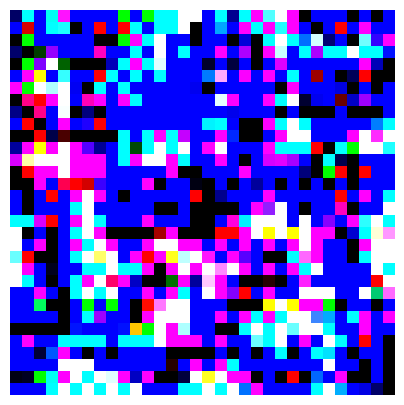

In [19]:
import numpy as np
import matplotlib.pyplot as plt

first_image = np.transpose(myarray[127, 0, :, :, :], (1, 2, 0))

plt.figure(figsize=(5, 5))
plt.imshow(first_image)
plt.axis('off')
plt.show()
